# Neural Cellular Automata (NCA) - A Complete Guide

---

**What is this notebook about?**

This notebook teaches you how to build **Neural Cellular Automata (NCA)** - a fascinating combination of:
- **Cellular Automata**: Simple rules applied to a grid of cells that create complex emergent patterns
- **Neural Networks**: Learnable rules that can be trained to produce specific outputs

We'll train an NCA to generate textures that match a target style image - with only **168 parameters**!

---

**Why is this exciting?**

1. **Emergent Complexity**: Simple local rules create complex global patterns
2. **Tiny Models**: Our NCA has only 168 parameters (vs millions in typical neural networks)
3. **Self-Organization**: The texture "grows" from nothing through local interactions
4. **Scalability**: Once trained, can generate textures at any resolution

---

**Prerequisites:**

This notebook builds on concepts from the Style Transfer notebook (16A). We'll use the same style loss based on Gram matrices and VGG features.

---

## Google Colab Setup

Run the cells below **once** at the start of each Colab session. They mount Google Drive, set the working directory, install required packages, and clone the `miniai` library from the fast.ai Part 2 course repo.

**GPU note:** NCA training is iterative and needs a GPU. Go to **Runtime &rarr; Change runtime type &rarr; GPU (T4)** before running.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.chdir('/content/drive/MyDrive/Fast.AI_Colab')
print(os.getcwd())

/content/drive/MyDrive/Fast.AI_Colab


In [3]:
!pip install -q fastcore fastai diffusers datasets torcheval accelerate
if not os.path.exists('course22p2'):
    !git clone https://github.com/fastai/course22p2.git
import sys
sys.path.insert(0, os.path.join(os.getcwd(), 'course22p2'))
try:
    import miniai
    print(f'miniai loaded from: {miniai.__file__}')
except ImportError:
    print('ERROR: miniai not found.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.2/179.2 kB 16.1 MB/s eta 0:00:00
miniai loaded from: /content/drive/MyDrive/Fast.AI_Colab/course22p2/miniai/__init__.py


---

*The cells above are Colab-specific setup. The content below is the same as the source notebook (`16B_NCA_explained.ipynb`), unchanged.*

---

## Section 1: Setup and Imports

In [4]:
# ============================================================================
# STANDARD PYTHON LIBRARIES
# ============================================================================

import pickle, gzip, math, os, time, shutil, torch, random, timm, torchvision, io, PIL, einops
# - pickle, gzip: Data serialization and compression
# - math: Mathematical functions
# - os, shutil: File system operations
# - time: Timing operations
# - torch: PyTorch - the main deep learning library
# - random: Random number generation
# - timm: PyTorch Image Models - pre-trained models
# - torchvision: Computer vision utilities
# - io, PIL: Image handling
# - einops: Elegant tensor operations (rearrange, repeat, etc.)

import fastcore.all as fc  # Utility library
import matplotlib as mpl   # Plotting
import numpy as np         # Numerical computing
import matplotlib.pyplot as plt  # Plotting interface

from collections.abc import Mapping
from pathlib import Path
from operator import attrgetter, itemgetter
from functools import partial
from copy import copy
from contextlib import contextmanager

# ============================================================================
# PYTORCH IMPORTS
# ============================================================================

import torchvision.transforms.functional as TF
import torch.nn.functional as F
from torchvision import transforms

from torch import tensor, nn, optim
from torch.utils.data import DataLoader, default_collate
from torch.nn import init
from torch.optim import lr_scheduler
from torcheval.metrics import MulticlassAccuracy
from datasets import load_dataset, load_dataset_builder
from fastcore.foundation import L, store_attr

# ============================================================================
# MINIAI IMPORTS
# ============================================================================

from miniai.datasets import *
from miniai.conv import *
from miniai.learner import *
from miniai.activations import *
from miniai.init import *
from miniai.sgd import *
from miniai.resnet import *

**What does the code above do?**

Imports all necessary libraries. Notable new import:

- **`einops`**: A library for elegant tensor reshaping. Instead of confusing `reshape`, `permute`, `transpose` chains, einops uses readable string notation like `'b c h w -> (b h w) c'`.

## 🛠️ Interactive visualizations — one-time setup

The cells marked **🎮 Interactive** below embed standalone HTML/JS visualizations
(stored in the `interactive_viz/` folder next to this notebook, and published on
GitHub Pages) at **full width**, auto-fitted to their content height.
Run the next cell once, then run any 🎮 cell.


In [5]:
# ============================================================================
# INTERACTIVE VISUALIZATIONS -- setup (run this cell ONCE).
# Each "🎮 Interactive" cell below loads a standalone HTML file from the
# published copy on GitHub Pages, in an isolated <iframe> (its CSS/JS can't leak
# into the notebook). It is shown FULL WIDTH and auto-fits its content height.
# No local files needed -- the visualizations are read from GitHub.
# ============================================================================
from IPython.display import HTML

def show_viz(path, height="600px"):
    """Embed an interactive visualization full width; it auto-fits its height.
    `path` may be a bare 'interactive_viz/<file>.html' (resolved to the GitHub
    Pages copy) or a full https URL."""
    base = "https://shammun.github.io/shammunul-fastai-notes/notebooks/"
    if not path.startswith("http"):
        path = base + path
    return HTML(
        f'<iframe src="{path}" loading="lazy" allowfullscreen '
        f'style="width:100%;height:{height};border:1px solid #dde5f2;border-radius:12px;'
        f'box-shadow:0 8px 24px rgba(123,92,214,.12);background:#fff;"></iframe>'
        '<script>addEventListener("message",function(e){'
        'if(e.data&&e.data.type==="ce-frame-height"&&e.data.height>50){'
        'var fs=document.querySelectorAll("iframe");for(var i=0;i<fs.length;i++){'
        'if(fs[i].contentWindow===e.source){fs[i].style.height=e.data.height+"px";break;}}}});</script>'
    )

---

## Section 2: Background - What are Cellular Automata?

Before diving into Neural Cellular Automata, let's understand the classic version.

### Classic Cellular Automata

A **cellular automaton** is a discrete model consisting of:

1. **A grid of cells**: Usually 2D (like a chessboard)
2. **Cell states**: Each cell has a state (e.g., "alive" or "dead")
3. **Update rules**: Rules that determine a cell's next state based on its **neighbors**
4. **Synchronous updates**: All cells update simultaneously

---

**Conway's Game of Life (1970)**

The most famous cellular automaton. Rules:

1. **Underpopulation**: A live cell with < 2 live neighbors dies
2. **Survival**: A live cell with 2-3 live neighbors survives
3. **Overpopulation**: A live cell with > 3 live neighbors dies
4. **Reproduction**: A dead cell with exactly 3 live neighbors becomes alive

```
Simple rules → Complex emergent behavior!

Step 0:        Step 1:        Step 2:        ...
□ □ □ □ □      □ □ □ □ □      □ □ □ □ □
□ □ ■ □ □      □ ■ ■ ■ □      □ □ ■ □ □
□ ■ ■ ■ □  →   □ □ ■ □ □  →   □ ■ □ ■ □  → ...
□ □ □ □ □      □ □ ■ □ □      □ □ ■ □ □
□ □ □ □ □      □ □ □ □ □      □ □ □ □ □
```

---

**Key Properties:**

- **Local rules**: Each cell only looks at its immediate neighbors
- **Emergent behavior**: Complex patterns emerge from simple rules
- **Self-organization**: Structure appears without central control

### 🎮 Interactive: Game of Life Lab — one tick of a tiny universe, dissected

Reading the rules is one thing — **watching them run is another**. The lab below is a live
Game of Life designed to be understood with zero prior knowledge. The **narration panel**
(purple box) tells you what is happening at every moment:

1. **Click any cell** on the grid (alive or dead — both are interesting).
2. Walk the stage chips **① → ② → ③ → ④**: pick the cell → highlight and count its
   8 neighbors (watch them **wrap around the edges** — the same *circular padding* our NCA
   uses!) → look up its fate in the rule table (the matching row lights up) → then stage ④
   shows a **frozen preview** of the whole next generation: green-dashed cells will be born,
   red-dashed cells will die, with counts and reasons. **Nothing changes until you press
   ✓ apply** — that pause is the point: every cell decides from the *current* grid, and all
   decisions are written at once (a *synchronous* update).
3. Then press **▶ Play** to run that same 4-stage loop automatically, fast.

Each **starting pattern** in the dropdown comes with its own explanation and a suggested
experiment — start with the *blinker* (simplest possible "animation": 3 cells) and the
*block* (a shape the rule can never change), then graduate to the *glider* and the
*r-pentomino* (5 cells that erupt into chaos).

The big idea to take away: the rule is *four lines* and each cell is *blind beyond its
3×3 neighborhood* — yet gliders **walk** and structure appears at the scale of the whole
grid. That gap between rule-size and pattern-size is **emergence**, and it's exactly what
NCA exploits (with a *learned* rule instead of B3/S23).

In [6]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/nca_game_of_life.html
# at full width, sized to fit the visualization (setup cell near the top required).
# Keep the 'interactive_viz' folder in the SAME directory as this notebook.
# ============================================================================
show_viz("interactive_viz/nca_game_of_life.html", height="840px")

### Neural Cellular Automata (NCA)

**Neural Cellular Automata** extend classic CA in two key ways:

1. **Continuous states**: Instead of binary (alive/dead), cells have continuous values (like RGB colors + extra channels)

2. **Learned rules**: Instead of hand-coded rules, we use a small neural network that learns the update rules through training

---

**How NCA works:**

```
┌─────────────────────────────────────────────────────────┐
│                    For each cell:                        │
│                                                          │
│  1. Look at neighbors    2. Neural network    3. Update  │
│     (perception)            (brain)              cell    │
│                                                          │
│    ┌───┬───┬───┐                                         │
│    │ N │ N │ N │                                         │
│    ├───┼───┼───┤      ┌─────────┐                        │
│    │ N │ X │ N │  →   │  tiny   │  →  X' (new state)     │
│    ├───┼───┼───┤      │   NN    │                        │
│    │ N │ N │ N │      └─────────┘                        │
│    └───┴───┴───┘                                         │
│                                                          │
└─────────────────────────────────────────────────────────┘
```

---

**Why NCA is powerful:**

- **Tiny models**: Just a few hundred parameters
- **Resolution independent**: Train on 128x128, run on any size
- **Self-healing**: Can recover from damage
- **Differentiable**: Can train with gradient descent

### What our NCA will create:

We'll train an NCA that, starting from random noise, evolves into a texture matching our target style image. The texture emerges through many small local updates - like watching crystals grow!

### Key References

If you want to learn more about NCA:

- [Growing Neural Cellular Automata](https://distill.pub/2020/growing-ca/) - A beautiful interactive paper that introduces NCA
- [Texture Generation with NCA](https://arxiv.org/abs/2105.07299) - The paper we're implementing today
- [The Future of AI is Self-Organizing](https://sebastianrisi.com/self_assembling_ai/) - Broader discussion of self-organizing AI
- [Fun with Neural Cellular Automata](https://wandb.ai/johnowhitaker/nca/reports/Fun-with-Neural-Cellular-Automata--VmlldzoyMDQ5Mjg0) - Many examples and experiments

---

## Section 3: Our Goal - Match a Style Image

We want our NCA to generate textures that look like a target style image.


The origianl code showed error and so we used a new code block below:

```python
def download_image(url):
    """
    Download an image from URL and convert to tensor.
    
    Parameters:
    -----------
    url : str
        URL of the image
        
    Returns:
    --------
    torch.Tensor
        Image tensor with shape (3, H, W), values in [0, 1]
    """
    # Download raw bytes from URL
    imgb = fc.urlread(url, decode=False)
    # Convert to tensor and decode image, normalize to [0, 1]
    return torchvision.io.decode_image(tensor(list(imgb), dtype=torch.uint8)).float() / 255.


# URL for our style image - a spiderweb with water droplets
url = "https://images.pexels.com/photos/34225/spider-web-with-water-beads-network-dewdrop.jpg?w=256"

# Download and move to GPU
style_im = download_image(url).to(def_device)

# Display the target style
show_image(style_im);

```

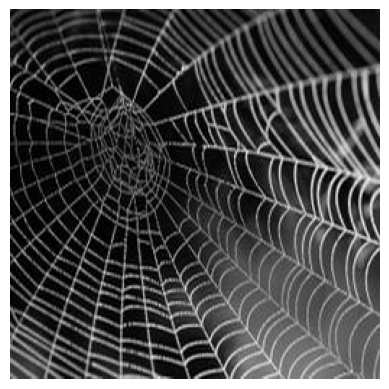

In [9]:
import io, requests
from PIL import Image
import numpy as np

def download_image(url, size=None):
    """
    Download an image from URL and convert to tensor.

    Returns
    -------
    torch.Tensor : shape (3, H, W), values in [0, 1]
    """
    headers = {"User-Agent": "Mozilla/5.0"}
    r = requests.get(url, headers=headers, timeout=30)
    r.raise_for_status()
    img = Image.open(io.BytesIO(r.content)).convert("RGB")
    if size is not None:
        img = img.resize(size if isinstance(size, tuple) else (size, size), Image.LANCZOS)
    return tensor(np.array(img)).permute(2, 0, 1).float() / 255.


url = "https://images.pexels.com/photos/34225/spider-web-with-water-beads-network-dewdrop.jpg?w=256"

style_im = download_image(url, size=256).to(def_device)
show_image(style_im);

**What does the code above do?**

Downloads and displays our target style image. The NCA will learn to generate textures with similar patterns - the web-like structures, the water droplets, the lighting.

**The amazing part:** We'll match this complex texture using only 168 trainable parameters!

---

## Section 4: Style Loss (from Notebook 16A)

We need a way to measure how similar our generated texture is to the target style. We'll use the same Gram matrix-based style loss from the Style Transfer notebook.

**Quick recap:**
- Extract features from VGG16 at multiple layers
- Compute Gram matrices (feature correlations, ignoring spatial location)
- Compare Gram matrices between generated and target images

In [10]:
# ============================================================================
# LOAD VGG16 FOR FEATURE EXTRACTION
# ============================================================================

# Load pretrained VGG16 (just the feature extraction part)
vgg16 = timm.create_model('vgg16', pretrained=True).to(def_device).features

# ImageNet normalization transform
normalize = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],  # ImageNet means for R, G, B
    std=[0.229, 0.224, 0.225]    # ImageNet stds for R, G, B
)


# ============================================================================
# FEATURE EXTRACTION FUNCTION
# ============================================================================

def calc_features(imgs, target_layers=[18, 25]):
    """
    Extract features from specific VGG16 layers.

    Parameters:
    -----------
    imgs : torch.Tensor
        Input images, shape (B, 3, H, W) or (3, H, W)
    target_layers : list of int
        Which VGG layers to extract features from

    Returns:
    --------
    list of torch.Tensor
        Feature maps from each target layer
    """
    # Normalize for VGG16
    x = normalize(imgs)
    feats = []
    # Pass through VGG layers sequentially
    for i, layer in enumerate(vgg16[:max(target_layers)+1]):
        x = layer(x)
        if i in target_layers:
            feats.append(x.clone())
    return feats


# ============================================================================
# GRAM MATRIX CALCULATION (BATCHED VERSION)
# ============================================================================

def calc_grams(img, target_layers=[1, 6, 11, 18, 25]):
    """
    Compute Gram matrices for VGG features.

    This is the BATCHED version - handles multiple images at once.

    Parameters:
    -----------
    img : torch.Tensor
        Input images, shape (B, 3, H, W)
    target_layers : list of int
        VGG layers to use

    Returns:
    --------
    L (list)
        Gram matrices for each layer
    """
    return L(
        # einsum: 'bchw, bdhw -> cd'
        # b: batch dimension (summed over - we average across batch)
        # c, d: channel dimensions (kept)
        # h, w: spatial dimensions (summed over)
        # Divide by h*w to normalize by spatial size
        torch.einsum('bchw, bdhw -> cd', x, x) / (x.shape[-2] * x.shape[-1])
        for x in calc_features(img, target_layers)
    )


# ============================================================================
# STYLE LOSS CLASS
# ============================================================================

class StyleLossToTarget():
    """
    Computes style loss between input images and a target style.

    Uses Gram matrices to capture texture/style independent of spatial location.

    Parameters:
    -----------
    target_im : torch.Tensor
        Target style image, shape (3, H, W)
    target_layers : list of int
        VGG layers to use for style comparison
    """
    def __init__(self, target_im, target_layers=[1, 6, 11, 18, 25]):
        fc.store_attr()
        # Pre-compute target Gram matrices
        # target_im[None] adds batch dimension: (3,H,W) -> (1,3,H,W)
        with torch.no_grad():
            self.target_grams = calc_grams(target_im[None], target_layers)

    def __call__(self, input_im):
        """
        Compute style loss.

        Parameters:
        -----------
        input_im : torch.Tensor
            Generated images, shape (B, 3, H, W)

        Returns:
        --------
        loss : torch.Tensor
            Sum of MSE between Gram matrices at each layer
        """
        # Compute Gram matrices for input and compare with target
        return sum(
            (f1 - f2).pow(2).mean()
            for f1, f2 in zip(calc_grams(input_im, self.target_layers), self.target_grams)
        )

model.safetensors:   0%|          | 0.00/553M [00:00<?, ?B/s]

**What does the code above do?**

Sets up the style loss from notebook 16A:

1. **`calc_features`**: Extracts feature maps from VGG16 layers
2. **`calc_grams`**: Computes Gram matrices (feature correlations)
3. **`StyleLossToTarget`**: Compares Gram matrices to measure style similarity

**Key difference from 16A:**

The `calc_grams` function here is **batched** - it processes multiple images at once:
- `'bchw, bdhw -> cd'` averages the Gram matrix across the batch
- This is more efficient for training

In [11]:
# Test the style loss with a random image
style_loss = StyleLossToTarget(style_im)

# Create random noise image: batch=1, channels=3, height=256, width=256
random_image = torch.rand(1, 3, 256, 256).to(def_device)

# Compute style loss between random noise and our target
# High value = very different style
style_loss(random_image)

tensor(1035.1664, device='cuda:0', grad_fn=<AddBackward0>)

**What does the code above do?**

Tests our style loss function by comparing random noise to the target style. The high loss value (around 1200) indicates they're very different - as expected!

During NCA training, we'll minimize this loss to make our generated textures match the target style.

---

## Section 5: Defining the NCA Model

Now let's build our Neural Cellular Automaton step by step.

### NCA Architecture Overview

Our NCA has two main components:

1. **Perception**: Each cell looks at its neighbors using convolution filters
2. **Brain**: A small neural network decides how to update based on what was perceived

```
┌─────────────────────────────────────────────────────────────┐
│                    NCA Update Step                          │
│                                                             │
│  Grid State      Perception         Brain         Update    │
│  (4 channels)    (filters)          (tiny NN)     (add)     │
│                                                             │
│  ┌─────────┐    ┌──────────┐      ┌─────────┐              │
│  │ 4 x H x W│ →  │4 filters │  →   │Linear+  │  →  Δstate   │
│  │         │    │per channel│      │ReLU+    │              │
│  │         │    │= 16 ch   │      │Linear   │              │
│  └─────────┘    └──────────┘      └─────────┘              │
│                                                             │
│  new_state = old_state + Δstate × update_mask              │
└─────────────────────────────────────────────────────────────┘
```

In [12]:
# ============================================================================
# NCA HYPERPARAMETERS
# ============================================================================

# Number of channels per cell
# - First 3 channels will be RGB (visible)
# - The 4th channel is a "hidden" state
num_channels = 4

# Hidden layer size in the "brain" network
hidden_n = 8

**What does the code above do?**

Sets key parameters:

- **`num_channels = 4`**: Each cell has 4 values:
  - Channels 0, 1, 2: RGB color (what we see)
  - Channel 3: Hidden state (internal memory)

- **`hidden_n = 8`**: The "brain" neural network has 8 hidden neurons.

**Why have hidden channels?**

The hidden channel lets cells communicate information that isn't directly visible. It's like cells having "internal thoughts" that influence their behavior.

In [13]:
def make_grids(n, sz=128):
    """
    Create a batch of empty (zeroed) grids for the NCA.

    Parameters:
    -----------
    n : int
        Number of grids (batch size)
    sz : int
        Size of each grid (sz x sz pixels)

    Returns:
    --------
    torch.Tensor
        Zeros tensor of shape (n, num_channels, sz, sz)
    """
    return torch.zeros(n, num_channels, sz, sz).to(def_device)

**What does the code above do?**

Creates empty grids (all zeros) that will be the starting state for our NCA. The NCA will evolve these zeros into textures!

### The Perception Step: Convolution Filters

Each cell needs to "see" its neighbors. We use 4 fixed (non-learnable) filters:

1. **Identity**: Just the cell itself
2. **Sobel X**: Horizontal edge detection (left-right differences)
3. **Sobel Y**: Vertical edge detection (up-down differences)  
4. **Laplacian**: Second derivative (detects edges in all directions)

In [14]:
# ============================================================================
# PERCEPTION FILTERS (Fixed, not learned)
# ============================================================================

filters = torch.stack([
    # Filter 1: Identity - just the center cell
    # Returns the cell's own value unchanged
    tensor([[0.0, 0.0, 0.0],
            [0.0, 1.0, 0.0],
            [0.0, 0.0, 0.0]]),

    # Filter 2: Sobel X - horizontal gradient
    # Detects left-right differences (vertical edges)
    # Negative on left, positive on right
    tensor([[-1.0, 0.0, 1.0],
            [-2.0, 0.0, 2.0],
            [-1.0, 0.0, 1.0]]),

    # Filter 3: Sobel Y - vertical gradient
    # Detects up-down differences (horizontal edges)
    # This is Sobel X transposed
    tensor([[-1.0, 0.0, 1.0],
            [-2.0, 0.0, 2.0],
            [-1.0, 0.0, 1.0]]).T,

    # Filter 4: Laplacian - second derivative
    # Detects areas where values change rapidly in any direction
    # The center is -12 (negative sum of neighbors weighted by distance)
    tensor([[1.0, 2.0, 1.0],
            [2.0, -12, 2.0],
            [1.0, 2.0, 1.0]])
]).to(def_device)

# Shape: (4, 3, 3) - 4 filters, each 3x3

**What does the code above do?**

Defines 4 perception filters that each cell uses to "see" its neighborhood:

| Filter | Purpose | What it detects |
|--------|---------|----------------|
| Identity | Self | The cell's own value |
| Sobel X | Horizontal gradient | Vertical edges (things changing left-right) |
| Sobel Y | Vertical gradient | Horizontal edges (things changing up-down) |
| Laplacian | Second derivative | Sharp changes in any direction |

**Visual intuition:**

```
Identity:     Sobel X:      Sobel Y:      Laplacian:
 0  0  0     -1  0  1      -1 -2 -1       1  2  1
 0  1  0     -2  0  2       0  0  0       2 -12 2
 0  0  0     -1  0  1       1  2  1       1  2  1
```

These filters give each cell information about:
- Its current value (identity)
- Changes to its left/right (Sobel X)
- Changes above/below (Sobel Y)
- Overall rate of change (Laplacian)

### 🎮 Interactive: Perception Filter Lab — see exactly what each filter detects

The table above tells you what the filters do — the lab below lets you **verify it
with your own eyes and your own arithmetic**:

- Pick a **filter** (Identity / Sobel X / Sobel Y / Laplacian) and a **pattern**
  (edges, blob, diagonal, flat). Press ▶ to sweep the filter across the grid.
- **Click any output cell** to see the exact 3×3 window, the element-wise products, and
  the sum — no magic, just multiply-and-add.
- Toggle **circular padding** on/off and watch the dashed orange "ghost" cells: with it ON,
  the window that hangs off the right edge grabs pixels from the *left* edge.
- Check the **flat** pattern: Sobels and Laplacian output exactly **0** everywhere.
  A cell in a uniform region literally *sees nothing* — it only perceives **change**.
- The thumbnail strip at the bottom shows all 4 filter responses at once; remember each
  of the 4 channels gets all 4 filters → **4 × 4 = 16 perception values per cell**.

In [15]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/nca_perception_filters.html
# at full width, sized to fit the visualization (setup cell near the top required).
# Keep the 'interactive_viz' folder in the SAME directory as this notebook.
# ============================================================================
show_viz("interactive_viz/nca_perception_filters.html", height="800px")

In [16]:
def perchannel_conv(x, filters):
    """
    Apply filters to each channel of the input separately.

    This is "per-channel" or "depthwise" convolution.
    Each channel gets the same set of filters applied to it.

    Parameters:
    -----------
    x : torch.Tensor
        Input tensor, shape (batch, channels, height, width)
    filters : torch.Tensor
        Filter kernels, shape (num_filters, h, w)

    Returns:
    --------
    torch.Tensor
        Output shape: (batch, channels * num_filters, height, width)
    """
    b, ch, h, w = x.shape

    # Step 1: Reshape to process each channel independently
    # (batch, channels, h, w) -> (batch*channels, 1, h, w)
    # This treats each channel as a separate single-channel image
    y = x.reshape(b * ch, 1, h, w)

    # Step 2: Pad with 'circular' mode
    # 'circular' means the grid wraps around (like a torus)
    # Left edge connects to right edge, top to bottom
    # Padding size [1,1,1,1] = 1 pixel on each side
    y = F.pad(y, [1, 1, 1, 1], 'circular')

    # Step 3: Apply the filters
    # filters[:, None] adds a dimension: (4, 3, 3) -> (4, 1, 3, 3)
    # This is required for conv2d which expects (out_ch, in_ch, h, w)
    y = F.conv2d(y, filters[:, None])

    # Step 4: Reshape back to batch format
    # (batch*channels, num_filters, h, w) -> (batch, channels*num_filters, h, w)
    return y.reshape(b, -1, h, w)

**What does the code above do?**

Applies perception filters to each channel of each cell:

1. **Reshape**: Treat each channel as an independent image
2. **Circular padding**: The grid wraps around (no edge effects)
3. **Convolution**: Apply all 4 filters
4. **Reshape back**: Combine into output tensor

**Why circular padding?**

```
Normal padding (zeros):      Circular padding:
┌─────────────┐              ┌─────────────┐
│ 0 0 0 0 0 0 │              │ C A B C A B │  (wraps!)
│ 0 A B C 0 0 │              │ F D E F D E │
│ 0 D E F 0 0 │   vs         │ I G H I G H │
│ 0 G H I 0 0 │              │ C A B C A B │  (wraps!)
│ 0 0 0 0 0 0 │              └─────────────┘
└─────────────┘
```

Circular padding creates a seamless, tileable texture. The texture has no "edges".

### 🎮 Interactive (3D): why "circular padding" = living on a torus 🍩

The ASCII diagram above shows circular padding in 2D. But there's a deeper — and honestly
more beautiful — way to see it: **a grid with wrap-around edges is exactly a grid drawn on
the surface of a donut (torus)**.

The 3D scene below (three.js — needs internet for the CDN) runs a live cellular automaton
on a flat sheet while you **fold the sheet up**:

- Drag the **fold slider** (or press ▶ Auto-fold): the sheet first **rolls into a
  cylinder** (the two orange left/right edges merge into one seam), then **bends into a
  torus** (the purple top/bottom edges merge too).
- Watch the gliders: on the flat sheet they seem to "teleport" across edges; on the torus
  you can see they were **never crossing an edge at all** — there are no edges.
- **Drag to rotate, scroll to zoom.**

This is also *why our NCA textures come out seamless and tileable*: the pattern must flow
continuously across the "edges", because on the torus those edges don't exist.

In [17]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/nca_torus_3d.html
# at full width, sized to fit the visualization (setup cell near the top required).
# Keep the 'interactive_viz' folder in the SAME directory as this notebook.
# ============================================================================
show_viz("interactive_viz/nca_torus_3d.html", height="780px")

In [18]:
# Test the perception step
x = make_grids(1)  # Create one empty grid

# Apply perception filters
model_inputs = perchannel_conv(x, filters)

# Check the output shape
# Input: (1, 4, 128, 128) - 1 batch, 4 channels, 128x128
# Output: (1, 16, 128, 128) - 1 batch, 4 channels × 4 filters = 16 channels
model_inputs.shape

torch.Size([1, 16, 128, 128])

**What does the output mean?**

- **Input**: (1, 4, 128, 128) - 4 channels per cell
- **Output**: (1, 16, 128, 128) - 16 values per cell

Each of the 4 channels gets 4 filter responses:
- 4 channels × 4 filters = 16 perception outputs

This is the "perception" - what each cell "sees" about itself and its neighbors.

### The Brain: A Tiny Neural Network

Now we need a "brain" that takes the perception (16 values) and outputs a state update (4 values).

We can implement this two ways - they're mathematically equivalent:

In [19]:
# ============================================================================
# APPROACH 1: Using Linear Layers (conceptually clearer)
# ============================================================================

# The "brain" network:
# Input: 16 (perception) -> Hidden: 8 -> Output: 4 (update)
brain = nn.Sequential(
    nn.Linear(num_channels * 4, hidden_n),  # 16 -> 8 # num_channels * 4 is the total number of inputs as there are 4 filters per channel. This is also the total number of filters
    nn.ReLU(),                               # Activation function
    nn.Linear(hidden_n, num_channels, bias=False)  # 8 -> 4, no bias # One output per channel as the update. There are 4 channels and with one output per channel, we have 4 outputs
    # In the second nn.Linear, we used bias=False because we are having these networks propose an update and if we want them to be stable, the update is usually going to be zero
    # or very small. If we had a bias, even if the input is zero, the output would be non-zero due to the bias, causing instability. We also want to keep the number of parameters low.
).to(def_device)

# So if we want to use the brain to process the entire grid, we need to deal with the extra dimension of height and width.


# Now, we have to rearrange our input that has 16 features, feed them through the linear layer, and then rearrange the outputs back to match the shape of our grid

# To use Linear layers, we need to reshape the input
# From: (batch, channels, height, width) = (1, 16, 128, 128)
# To: (batch*height*width, channels) = (16384, 16)
# This treats each cell as an independent sample
model_inputs_flat = einops.rearrange(model_inputs, 'b c h w -> (b h w) c')
print(f"Flattened shape: {model_inputs_flat.shape}")

# Apply the brain to each cell
brain_preds = brain(model_inputs_flat)
print(f"Brain output (flat): {brain_preds.shape}")

# Reshape back to grid format
brain_preds = brain_preds.reshape(x.shape)
print(f"Brain output (grid): {brain_preds.shape}")

Flattened shape: torch.Size([16384, 16])
Brain output (flat): torch.Size([16384, 4])
Brain output (grid): torch.Size([1, 4, 128, 128])


**What does the code above do?**

Creates the "brain" using standard Linear layers:

1. **`nn.Linear(16, 8)`**: First layer, 16 inputs → 8 hidden neurons
2. **`nn.ReLU()`**: Non-linear activation (allows complex patterns)
3. **`nn.Linear(8, 4, bias=False)`**: Second layer, 8 → 4 outputs

**The `einops.rearrange` magic:**

```python
einops.rearrange(model_inputs, 'b c h w -> (b h w) c')
```

This reads as: "Take a tensor with dimensions batch, channels, height, width, and rearrange to (batch×height×width, channels)"

- Input: (1, 16, 128, 128)
- Output: (1×128×128, 16) = (16384, 16)

Each of the 16384 cells is now a row with 16 features!

# Understanding the "Brain" Network in Neural Cellular Automata

## Context: What is this code doing?

This code is from a **Neural Cellular Automata (NCA)** notebook. The "brain" is a tiny neural network that decides how each cell should update based on what it "sees" in its neighborhood.

---

## Initial Setup

```python
num_channels = 4    # Each cell has 4 channels (like RGBA)
hidden_n = 8        # Hidden layer size in the brain
```

---

## Step 1: Input to the Brain

Before the brain, there's a **perception step** that applies 4 filters to each of the 4 channels:

```python
x = make_grids(1)                           # Shape: (1, 4, 128, 128)
model_inputs = perchannel_conv(x, filters)  # Shape: (1, 16, 128, 128)
```

- **Input x**: 1 batch, 4 channels, 128×128 grid
- **After perception**: 1 batch, 16 channels (4 channels × 4 filters), 128×128 grid

Each cell now has **16 values** describing what it "sees":
- 4 values for its own state (identity filter)
- 4 values for horizontal gradients (Sobel X)
- 4 values for vertical gradients (Sobel Y)  
- 4 values for rate of change (Laplacian)

---

## Step 2: The Brain Architecture

```python
brain = nn.Sequential(
    nn.Linear(num_channels * 4, hidden_n),           # Linear(16, 8)
    nn.ReLU(),                                        # Activation
    nn.Linear(hidden_n, num_channels, bias=False)    # Linear(8, 4)
).to(def_device)
```

The brain is a simple MLP:

```
Input (16) ──► Linear(16→8) ──► ReLU ──► Linear(8→4) ──► Output (4)
              (with bias)              (no bias)
```

**Why `bias=False` in the second layer?**
- The brain outputs an **update** (change to apply to the cell)
- We want stable patterns, so updates should often be near zero
- If there was a bias, even zero input would produce non-zero output
- Also keeps parameter count low

---

## Step 3: Reshaping for Linear Layers

`nn.Linear` expects 2D input: `(batch, features)`. But we have 4D: `(batch, channels, height, width)`.

**Solution**: Treat each pixel as a separate "sample":

```python
model_inputs_flat = einops.rearrange(model_inputs, 'b c h w -> (b h w) c')
# Shape: (1*128*128, 16) = (16384, 16)
```

### What the einops notation means:

```
'b c h w -> (b h w) c'
 │ │ │ │    └──┬──┘ │
 │ │ │ │       │    └── channels become features (last dim)
 │ │ │ │       └─────── batch, height, width combined into one dim
 │ │ │ └── width
 │ │ └── height  
 │ └── channels
 └── batch

Before: (1, 16, 128, 128)
        └┘ └─┘ └───────┘
      batch ch   spatial

After:  (16384, 16)
        └────┘  └─┘
     1×128×128  channels
     (all pixels)
```

---

## Step 4: Passing Through Each Layer

Now let's trace the exact shapes through the brain:

### Input: `model_inputs_flat`
```
Shape: (16384, 16)
       └────┘  └─┘
    16384 pixels, each with 16 perception values
```

### Layer 1: `nn.Linear(16, 8)`

```python
# Weight matrix: (8, 16)
# Bias vector: (8,)
# Operation: output = input @ weight.T + bias

Input:  (16384, 16)
Weight: (8, 16)  → transposed to (16, 8) for matmul
Bias:   (8,)

Computation: (16384, 16) @ (16, 8) + (8,) = (16384, 8)

Output: (16384, 8)
```

**What happens**: Each pixel's 16 perception values are projected to 8 hidden values.

### Layer 2: `nn.ReLU()`

```python
# Operation: output = max(0, input)

Input:  (16384, 8)
Output: (16384, 8)  # Shape unchanged, negative values become 0
```

**What happens**: Non-linearity applied. Negative values clamped to zero.

### Layer 3: `nn.Linear(8, 4, bias=False)`

```python
# Weight matrix: (4, 8)
# No bias!
# Operation: output = input @ weight.T

Input:  (16384, 8)
Weight: (4, 8)  → transposed to (8, 4) for matmul

Computation: (16384, 8) @ (8, 4) = (16384, 4)

Output: (16384, 4)
```

**What happens**: Each pixel's 8 hidden values are projected to 4 update values (one per channel).

---

## Step 5: Reshape Back to Grid

```python
brain_preds = brain(model_inputs_flat).reshape(x.shape)
# x.shape is (1, 4, 128, 128)
```

```
Before: (16384, 4)
        └────┘  └┘
     1×128×128  channels

After:  (1, 4, 128, 128)
        └┘ └┘ └───────┘
      batch ch  spatial
```

**Why reshape?** We need the grid format `(B, C, H, W)` to:
- Add the update to the current state
- Apply further convolutions
- Display as an image

---

## Complete Flow Diagram

```
┌─────────────────────────────────────────────────────────────────────────────────┐
│                              COMPLETE DATA FLOW                                  │
│                                                                                 │
│  x: (1, 4, 128, 128)           ← Original grid (4 channels per cell)            │
│         │                                                                       │
│         ▼                                                                       │
│  perchannel_conv(x, filters)   ← Apply 4 perception filters to each channel     │
│         │                                                                       │
│         ▼                                                                       │
│  model_inputs: (1, 16, 128, 128)  ← 4 channels × 4 filters = 16 perception vals │
│         │                                                                       │
│         ▼                                                                       │
│  einops.rearrange('b c h w -> (b h w) c')                                       │
│         │                                                                       │
│         ▼                                                                       │
│  model_inputs_flat: (16384, 16)   ← Each pixel is now a "sample"                │
│         │                                                                       │
│         ▼                                                                       │
│  ┌─────────────────────────────────────────────────────────────────────────┐    │
│  │                            BRAIN NETWORK                                │    │
│  │                                                                         │    │
│  │  Input: (16384, 16)                                                     │    │
│  │         │                                                               │    │
│  │         ▼                                                               │    │
│  │  ┌─────────────────────────────────────────────────────────────────┐    │    │
│  │  │ nn.Linear(16, 8)                                                │    │    │
│  │  │   Weight: (8, 16) = 128 parameters                              │    │    │
│  │  │   Bias: (8,) = 8 parameters                                     │    │    │
│  │  │   Output: (16384, 8)                                            │    │    │
│  │  └─────────────────────────────────────────────────────────────────┘    │    │
│  │         │                                                               │    │
│  │         ▼                                                               │    │
│  │  ┌─────────────────────────────────────────────────────────────────┐    │    │
│  │  │ nn.ReLU()                                                       │    │    │
│  │  │   Output: (16384, 8)  ← shape unchanged                         │    │    │
│  │  └─────────────────────────────────────────────────────────────────┘    │    │
│  │         │                                                               │    │
│  │         ▼                                                               │    │
│  │  ┌─────────────────────────────────────────────────────────────────┐    │    │
│  │  │ nn.Linear(8, 4, bias=False)                                     │    │    │
│  │  │   Weight: (4, 8) = 32 parameters                                │    │    │
│  │  │   No bias!                                                      │    │    │
│  │  │   Output: (16384, 4)                                            │    │    │
│  │  └─────────────────────────────────────────────────────────────────┘    │    │
│  │                                                                         │    │
│  │  Total parameters: 128 + 8 + 32 = 168                                   │    │
│  └─────────────────────────────────────────────────────────────────────────┘    │
│         │                                                                       │
│         ▼                                                                       │
│  brain output: (16384, 4)         ← 4 update values per pixel                   │
│         │                                                                       │
│         ▼                                                                       │
│  .reshape(x.shape)                ← Reshape back to grid format                 │
│         │                                                                       │
│         ▼                                                                       │
│  brain_preds: (1, 4, 128, 128)    ← Update values in grid format                │
│                                                                                 │
└─────────────────────────────────────────────────────────────────────────────────┘
```

---

## Summary Table

| Step | Shape | Description |
|------|-------|-------------|
| Input grid `x` | `(1, 4, 128, 128)` | 4-channel grid |
| After perception | `(1, 16, 128, 128)` | 16 perception values per cell |
| After rearrange | `(16384, 16)` | Flattened for Linear layers |
| After Linear(16,8) | `(16384, 8)` | Project to hidden |
| After ReLU | `(16384, 8)` | Non-linearity |
| After Linear(8,4) | `(16384, 4)` | Project to update |
| After reshape | `(1, 4, 128, 128)` | Back to grid format |

---

## Why Do We Do This?

1. **`nn.Linear` requires 2D input**: It expects `(batch, features)`, not 4D image tensors.

2. **Per-pixel processing**: The brain processes each pixel **independently**, applying the same 168 parameters to all 16,384 pixels. This is the essence of cellular automata - the same local rule everywhere.

3. **Reshape back**: After processing, we need the image format `(B, C, H, W)` to add the update to the current state and continue the NCA evolution.

---

## The Parameters

```python
[p.shape for p in brain.parameters()]
# [torch.Size([8, 16]), torch.Size([8]), torch.Size([4, 8])]
```

| Parameter | Shape | Count | Layer |
|-----------|-------|-------|-------|
| Weight 1 | `(8, 16)` | 128 | `Linear(16, 8)` |
| Bias 1 | `(8,)` | 8 | `Linear(16, 8)` |
| Weight 2 | `(4, 8)` | 32 | `Linear(8, 4)` |
| **Total** | | **168** | |

**Amazing fact**: These 168 parameters, applied identically to every cell, can generate complex textures through self-organization!

In [20]:
# Check the parameter shapes of the Linear-based brain
[p.shape for p in brain.parameters()]

[torch.Size([8, 16]), torch.Size([8]), torch.Size([4, 8])]

**Parameter shapes for Linear approach:**

- `[8, 16]`: First layer weights (8 outputs × 16 inputs = 128 params)
- `[8]`: First layer bias (8 params)
- `[4, 8]`: Second layer weights (4 outputs × 8 inputs = 32 params)

Total: 128 + 8 + 32 = **168 parameters**

We have 8 by 16 inputs and 8 biases for the first layer. And then we just have a 4 by 8 weight matrix for the second linear layer.

In [21]:
# ============================================================================
# APPROACH 2: Using 1x1 Convolutions (more efficient)
# ============================================================================

# A 1x1 convolution is mathematically equivalent to applying a Linear layer
# to each spatial position independently!
brain = nn.Sequential(
    nn.Conv2d(num_channels * 4, hidden_n, 1),  # 1x1 conv: 16 -> 8 -- filter size of 1 means
    nn.ReLU(),
    nn.Conv2d(hidden_n, num_channels, 1, bias=False)  # 1x1 conv: 8 -> 4
).to(def_device)

# No reshaping needed! Conv2d handles the spatial dimensions
brain_preds = brain(model_inputs).reshape(x.shape)
brain_preds.shape

torch.Size([1, 4, 128, 128])

**What does the code above do?**

Uses 1×1 convolutions instead of Linear layers.

**Key insight:** A 1×1 convolution is mathematically identical to applying a Linear layer at each spatial position!

```
1x1 Convolution:
┌───────────────────────┐
│ For each position:    │
│   output = W × input  │
│                       │
│ Same weights W used   │
│ at every position!    │
└───────────────────────┘
```

**Advantages of 1×1 conv:**
- No reshaping needed (more efficient)
- Works directly on image tensors
- Same number of parameters

In [22]:
# Check the parameter shapes of the Conv-based brain
[p.shape for p in brain.parameters()]

[torch.Size([8, 16, 1, 1]), torch.Size([8]), torch.Size([4, 8, 1, 1])]

**Parameter shapes for Conv approach:**

- `[8, 16, 1, 1]`: First layer weights (8 out × 16 in × 1 × 1)
- `[8]`: First layer bias
- `[4, 8, 1, 1]`: Second layer weights (4 out × 8 in × 1 × 1)

Same total: 8×16 + 8 + 4×8 = **168 parameters**

The extra `1, 1` dimensions are for the kernel size (1×1).

### 🎮 Interactive: the 168-parameter brain — Linear layers ≡ 1×1 convolutions

You've now seen the *same* brain written two ways with the *same* 168 parameters. The
visualization below makes both claims tangible:

- The **network diagram** shows all of it: 16 inputs (color-grouped by channel) → 8 hidden
  (ReLU — gray nodes were clipped to zero) → 4 outputs (ΔR, ΔG, ΔB, Δhidden).
  **Hover any neuron** to light up its incoming weights (teal = positive, red = negative,
  thickness = magnitude). **🎲 New input** pushes a fresh perception vector through.
- Toggle **nn.Linear vs. nn.Conv2d 1×1** — the parameter table updates its shapes
  (`[8, 16]` vs `[8, 16, 1, 1]`) but the count and the math stay identical. A 1×1 conv
  *is* a Linear layer applied independently at every pixel.
- The **training-progress slider** shows why we zero-initialize `w2`: at 0%, every cell's
  update Δ is exactly **0**, so the untrained NCA starts perfectly stable instead of
  exploding into noise on step one.

In [23]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/nca_brain_1x1conv.html
# at full width, sized to fit the visualization (setup cell near the top required).
# Keep the 'interactive_viz' folder in the SAME directory as this notebook.
# ============================================================================
show_viz("interactive_viz/nca_brain_1x1conv.html", height="790px")

### Putting It Together: The SimpleCA Class

Let's combine perception and brain into a complete NCA with a few extra features:

1. **Random update**: Only update ~50% of cells each step (adds randomness)
2. **to_rgb function**: Extract the visible RGB channels
3. **Zero initialization**: Start with zeros in the output layer (why? see below)

In [24]:
class SimpleCA(nn.Module):
    """
    A simple Neural Cellular Automaton.

    Each update step:
    1. Perceive: Apply filters to see neighbors
    2. Think: Pass through neural network "brain"
    3. Update: Add predicted change to state (with random mask)

    Parameters:
    -----------
    zero_w2 : bool
        If True, initialize second layer weights to zero.
        This means the NCA starts doing nothing and learns gradually.
    """
    def __init__(self, zero_w2=True):
        super().__init__()

        # The "brain" network: 16 -> 8 -> 4
        self.w1 = nn.Conv2d(num_channels * 4, hidden_n, 1)  # First layer
        self.relu = nn.ReLU()                                # Activation
        self.w2 = nn.Conv2d(hidden_n, num_channels, 1, bias=False)  # Second layer

        # Optionally zero the output layer weights
        if zero_w2:
            self.w2.weight.data.zero_()

    def forward(self, x, update_rate=0.5):
        """
        One NCA update step.

        Parameters:
        -----------
        x : torch.Tensor
            Current grid state, shape (batch, channels, height, width)
        update_rate : float
            Probability of updating each cell (default 0.5)

        Returns:
        --------
        torch.Tensor
            New grid state (same shape as input)
        """
        # Step 1: PERCEIVE - Apply filters to see neighbors
        y = perchannel_conv(x, filters)

        # Step 2: THINK - Pass through the brain network
        y = self.w2(self.relu(self.w1(y)))

        # Step 3: RANDOM UPDATE MASK
        # Only update some cells each step (adds stochasticity)
        b, c, h, w = y.shape
        # torch.rand generates values in [0, 1)
        # Adding update_rate and flooring gives ~update_rate probability of 1
        # Shape: (batch, 1, h, w) - same mask for all channels
        update_mask = (torch.rand(b, 1, h, w).to(x.device) + update_rate).floor()
        # Why shape (b, 1, h, w)? The 1 in the channel dimension means the same mask applies to all 4 channels of each cell. Either the whole cell updates, or none of it does.

        # Step 4: UPDATE - Add the change, masked by random selection
        # new_state = old_state + delta * mask
        return x + y * update_mask

    def to_rgb(self, x):
        """
        Extract RGB channels from the state and shift for display.

        Parameters:
        -----------
        x : torch.Tensor
            Grid state with shape (..., 4, H, W)

        Returns:
        --------
        torch.Tensor
            RGB image with shape (..., 3, H, W), values centered around 0.5
        """
        # Take first 3 channels (RGB) and add 0.5 to center around middle gray
        # The NCA state is centered around 0, but images should be [0, 1]
        return x[..., :3, :, :] + 0.5
        # The `...` (ellipsis) means "all preceding dimensions, whatever they are."
        # So `:3` selects channels 0, 1, 2 (the RGB channels).

**What does the code above do?**

Defines the complete NCA model:

**`__init__`:**
- Creates the brain network (w1 → ReLU → w2)
- Optionally zeros the output layer

**`forward`:**
1. **Perceive**: Apply filters to see neighbors (16 values per cell)
2. **Think**: Process through brain network (16 → 8 → 4)
3. **Mask**: Generate random mask (~50% of cells update)
4. **Update**: Add change to current state

**`to_rgb`:**
- Extracts channels 0, 1, 2 as RGB
- Adds 0.5 to shift from [-0.5, 0.5] to [0, 1]

---

**Why zero the output layer (`zero_w2=True`)?**

When `w2` weights are zero:
- The model initially outputs zero change
- The grid stays unchanged at first
- The model learns to make changes gradually

This prevents the model from making wild random changes at the start of training!

---

**Why random update mask?**

If all cells update simultaneously:
- Patterns can become too regular/synchronized
- Information can't travel far in one step

Random updates:
- Break symmetry
- Create more organic-looking patterns
- Make the system more robust

### 🎮 Interactive: one NCA step, running LIVE in your browser

Everything in `SimpleCA.forward` — the perception filters, a 168-parameter brain, the
random mask, the residual add — is **re-implemented in JavaScript below and actually
running** on a 24×24 grid (with a *random, untrained* brain, so it doodles rather than
paints spiderwebs — training is precisely the search for the 168 numbers that doodle
*your target texture*).

- The four **stage chips** mirror the four lines of `forward`; click one to jump there and
  the highlighted code line follows. Use **next stage ⏭** to crawl through a single update.
- Panels light up as data flows: grid → **① 16 perception maps** → **② proposed update Δ**
  (teal = increase, red = decrease) → **③ random mask** (purple cells update this step)
  → **④ back into the grid**.
- Drag **update_rate**: at 1.0 all cells march in lock-step; at ~0.5 (the default in our
  model) updates are asynchronous — this randomness is what makes trained NCA textures
  robust and organic, since real cells don't share a global clock.
- Note the **residual** update `x = x + Δ·mask`: cells *nudge* themselves rather than being
  overwritten. Small smooth changes → stable dynamics and easy gradients.

In [25]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/nca_update_pipeline.html
# at full width, sized to fit the visualization (setup cell near the top required).
# Keep the 'interactive_viz' folder in the SAME directory as this notebook.
# ============================================================================
show_viz("interactive_viz/nca_update_pipeline.html", height="1000px")

# The Difference Between `x[..., :3, :, :]` and `x[:, :3, :, :]`

## Short Answer

Both work **for 4D tensors**, but `...` (ellipsis) is **more flexible** and works for tensors of **any number of dimensions**.

---

## What Each Notation Means

### `x[:, :3, :, :]` — Explicit 4D

This **explicitly specifies 4 dimensions**:

```python
x[:, :3, :, :]
  │   │   │  │
  │   │   │  └── dimension 3 (width): all
  │   │   └───── dimension 2 (height): all
  │   └───────── dimension 1 (channels): first 3
  └───────────── dimension 0 (batch): all
```

**Only works for exactly 4D tensors.**

### `x[..., :3, :, :]` — Flexible with Ellipsis

The `...` means **"all preceding dimensions, whatever they are"**:

```python
x[..., :3, :, :]
   │    │   │  │
   │    │   │  └── last dimension (width): all
   │    │   └───── second-to-last (height): all
   │    └───────── third-to-last (channels): first 3
   └───────────── everything before that: all
```

**Works for 4D, 5D, 3D, etc.**

---

## Practical Examples

### Case 1: 4D Tensor (Both Work)

```python
x = torch.randn(2, 4, 128, 128)  # (batch, channels, height, width)

# Both give the same result:
x[:, :3, :, :].shape    # torch.Size([2, 3, 128, 128])
x[..., :3, :, :].shape  # torch.Size([2, 3, 128, 128])
```

### Case 2: 3D Tensor (Only Ellipsis Works)

```python
x = torch.randn(4, 128, 128)  # (channels, height, width) - no batch!

x[..., :3, :, :].shape  # torch.Size([3, 128, 128]) ✓
x[:, :3, :, :].shape    # ERROR! Too many indices ✗
```

### Case 3: 5D Tensor (Only Ellipsis Works)

```python
x = torch.randn(2, 3, 4, 128, 128)  # (batch, time, channels, height, width)

x[..., :3, :, :].shape  # torch.Size([2, 3, 3, 128, 128]) ✓
x[:, :3, :, :].shape    # Wrong result! Slices time dimension ✗
```

---

## Why Use Ellipsis in `to_rgb`?

```python
def to_rgb(self, x):
    return x[..., :3, :, :] + 0.5
```

The `to_rgb` method might be called with:

| Input Shape | What it is | Ellipsis handles it |
|-------------|------------|---------------------|
| `(4, 128, 128)` | Single image, no batch | ✓ |
| `(1, 4, 128, 128)` | Batched image | ✓ |
| `(8, 4, 128, 128)` | Multiple images | ✓ |
| `(2, 10, 4, 128, 128)` | Batch × time steps | ✓ |

Using `...` makes the function **robust to different input shapes**.

---

## Visual Summary

```
x[:, :3, :, :]          x[..., :3, :, :]
      │                       │
      ▼                       ▼
"Exactly 4 dims"        "Any number of dims"
      │                       │
      ▼                       ▼
┌─────────────┐         ┌─────────────┐
│ dim0: all   │         │ ...: all    │ ← "whatever comes before"
│ dim1: :3    │         │ dim-3: :3   │ ← third from last
│ dim2: all   │         │ dim-2: all  │ ← second from last
│ dim3: all   │         │ dim-1: all  │ ← last
└─────────────┘         └─────────────┘
      │                       │
      ▼                       ▼
Only works for          Works for 3D, 4D,
4D tensors              5D, etc.
```

---

## Summary

| Notation | Flexibility | Use Case |
|----------|-------------|----------|
| `x[:, :3, :, :]` | Only 4D | When you know exact dimensions |
| `x[..., :3, :, :]` | Any dimensions | When input shape may vary |

The NCA code uses `...` to be **flexible** — the same `to_rgb` function works whether you pass a single image or a batch of images.

---

## Section 6: Training the NCA

Now let's set up the training loop. NCA training has some unique aspects.

In [26]:
# ============================================================================
# DUMMY DATALOADERS (same as Style Transfer notebook)
# ============================================================================

class LengthDataset():
    """
    A dummy dataset that just counts iterations.
    We don't actually load data - we generate NCA states.
    """
    def __init__(self, length=1):
        self.length = length
    def __len__(self):
        return self.length
    def __getitem__(self, idx):
        return 0, 0  # Dummy data, not used


def get_dummy_dls(length=100):
    """
    Create dummy DataLoaders for NCA training.

    The 'length' controls how many training steps per epoch.
    """
    return DataLoaders(
        DataLoader(LengthDataset(length), batch_size=1),
        DataLoader(LengthDataset(1), batch_size=1)
    )

**What does the code above do?**

Creates fake DataLoaders because:
- We don't load images from a dataset
- Instead, we maintain a "pool" of evolving NCA grids
- The DataLoader just controls how many training iterations we do

### Custom Progress Callback

Let's create a callback that shows both the loss curve and preview images during training.

In [27]:
class NCAProgressCB(ProgressCB):
    """
    Progress callback with live visualization for NCA training.

    Shows:
    - Loss curve (log scale)
    - Preview of generated textures
    """

    def after_batch(self, learn):
        """
        Called after each training batch.
        Updates the progress display with loss and preview images.
        """
        # Update the progress bar comment with current loss
        learn.dl.comment = f'{learn.loss:.3f}'

        # Only track metrics during training
        if not (hasattr(learn, 'metrics') and learn.training):
            return

        # Store the loss value
        self.losses.append(learn.loss.item())
        mbar = self.mbar

        # Create the figure on first call
        if not hasattr(mbar, 'graph_fig'):
            # Create figure with 2 subplots: loss curve (left), preview (right)
            mbar.graph_fig, mbar.graph_axs = plt.subplots(1, 2, figsize=(12, 3.5))
            mbar.graph_out = display(mbar.graph_fig, display_id=True)

        # Only update display every 64 iterations (to avoid slowdown)
        if (len(self.losses)) % 64 != 10:
            return

        # Plot loss curve on log scale
        mbar.graph_axs[0].clear()
        mbar.graph_axs[0].plot(self.losses, '.', alpha=0.3)
        mbar.graph_axs[0].set_yscale('log')  # Log scale shows progress better
        mbar.graph_axs[0].set_ylim(tensor(self.losses).min(), self.losses[0])

        # Show preview images
        # Convert NCA state to RGB and clip to valid range
        rgb = learn.model.to_rgb(learn.preds.detach()).clip(0, 1)
        # make_grid arranges multiple images into a single grid
        show_image(torchvision.utils.make_grid(rgb), ax=mbar.graph_axs[1])

        # Update the display
        mbar.graph_out.update(mbar.graph_fig)

**What does the code above do?**

Creates a custom progress callback that:

1. **Tracks losses**: Stores loss values in a list
2. **Plots loss curve**: Shows how loss decreases over time (log scale)
3. **Shows previews**: Displays the current generated textures
4. **Updates periodically**: Only refreshes every 64 steps (for performance)

This gives us live feedback during the ~20 minute training process!

### The NCA Training Callback

This is the heart of NCA training. It handles:
1. Maintaining a "pool" of evolving grids
2. Running the NCA for multiple steps
3. Computing the loss
4. Gradient normalization

In [28]:
class NCACB(TrainCB):
    """
    Training callback for Neural Cellular Automata.

    Key concepts:
    1. Pool: We maintain a "pool" of evolving grids, not just one
    2. Multi-step: Each training iteration runs the NCA 32-96 times
    3. Sample reuse: Grids from the pool are reused across iterations

    Parameters:
    -----------
    ca : SimpleCA
        The NCA model
    style_img_tensor : torch.Tensor
        Target style image
    style_loss_scale : float
        Weight for style loss (default 0.1)
    size : int
        Grid size (default 256)
    step_n_min, step_n_max : int
        Range of NCA steps per training iteration
    batch_size : int
        Number of grids to train on at once
    """
    order = DeviceCB.order + 1  # Run after DeviceCB

    def __init__(self, ca, style_img_tensor, style_loss_scale=0.1, size=256,
                 step_n_min=32, step_n_max=96, batch_size=4):
        fc.store_attr()

        # Create a "pool" of 256 grids
        # These grids persist across training iterations
        # They evolve over time, getting better and better
        with torch.no_grad():
            self.pool = make_grids(256, sz=size)

    def predict(self, learn):
        """
        Generate predictions by running the NCA multiple times.
        """
        # Step 1: Pick random samples from the pool
        batch_idx = torch.randint(0, len(self.pool), (self.batch_size,))
        x = self.pool[batch_idx]

        # Step 2: Occasionally reset some grids to zero
        # This ensures the NCA can always grow from nothing
        # (prevents "cheating" by only learning to maintain existing patterns)
        if torch.randint(8, (1,)) < 1:  # ~12.5% chance
            x[:1] = make_grids(1, sz=self.size)  # Reset first grid

        # Step 3: Run the NCA for a random number of steps (32-96)
        # This teaches the NCA to maintain patterns over varying durations
        for _ in range(torch.randint(self.step_n_min, self.step_n_max, (1,))):
            x = learn.model(x)

        # Step 4: Update the pool with the evolved grids
        # This is key - grids persist and continue evolving!
        with torch.no_grad():
            self.pool[batch_idx] = x

        # Store predictions
        learn.preds = x

    def get_loss(self, learn):
        """
        Compute the training loss.

        Two components:
        1. Style loss: Match the target texture
        2. Overflow loss: Keep values in valid range
        """
        # Style loss: How different is our texture from the target?
        style_loss = learn.loss_func(learn.model.to_rgb(self.learn.preds))

        # Overflow loss: Penalize values outside [-1, 1]
        # This keeps the NCA from "exploding" to very large values
        overflow_loss = (learn.preds - learn.preds.clamp(-1.0, 1.0)).abs().sum()

        # Combined loss
        learn.loss = overflow_loss + style_loss * self.style_loss_scale

    def backward(self, learn):
        """
        Custom backward pass with gradient normalization.
        """
        learn.loss.backward()

        # Gradient normalization: Scale each parameter's gradient
        # by the gradient's norm. This prevents any single parameter
        # from dominating the update.
        for p in learn.model.parameters():
            p.grad /= (p.grad.norm() + 1e-8)  # +1e-8 prevents division by zero

    def before_fit(self, learn):
        """Store reference to learner for use in get_loss."""
        self.learn = learn

**What does the code above do?**

This is the most complex part - let's break it down:

---

**The Pool Concept:**

We maintain 256 grids that persist across training iterations:

```
Pool of 256 grids:
┌─────┬─────┬─────┬───────┬─────┐
│Grid1│Grid2│Grid3│  ...  │Grid256│
└─────┴─────┴─────┴───────┴─────┘
   ↓      ↓
Each iteration: Pick 4 random grids, evolve them, put them back
```

Why? This allows patterns to develop over many training iterations, not just within one forward pass.

---

**Multi-Step Training:**

Each iteration runs the NCA 32-96 times:
- Teaches the NCA to maintain patterns over time
- Random step count prevents overfitting to specific durations

---

**Occasional Reset:**

~12.5% of the time, we reset a grid to zeros:
- Ensures the NCA can grow patterns from scratch
- Prevents the model from only learning to maintain existing patterns

---

**Two Loss Components:**

1. **Style loss**: Match target texture (Gram matrix comparison)
2. **Overflow loss**: Penalize values outside [-1, 1] to keep them bounded

---

**Gradient Normalization:**

Dividing gradients by their norm:
```python
p.grad /= (p.grad.norm() + 1e-8)
```

This makes all gradients have roughly unit norm, which:
- Stabilizes training
- Prevents any single parameter from being updated too much

### 🎮 Interactive: watch the pool trick keep training honest

The pool is the least intuitive part of NCA training, so here it is **animated end to
end**. Press **▶ Play training** and watch the 256-tile pool "ripen" from gray (fresh
zeros) to teal (grids that have lived for thousands of NCA steps):

- **① sample 4** grids (orange outlines) — **② every 8th iteration, reset one to zeros**
  (red outline) so the model never forgets how to *start* a texture from nothing —
  **③ evolve them a random 32–96 steps** — **④ style loss** against the target (watch the
  log-scale loss curve fall) — **⑤ backprop, then normalize each parameter's gradient to
  unit length** (compare the wild raw-gradient bar vs. the steady normalized one — that's
  what tames backprop through up to 96 chained steps) — **⑥ write the batch back**.
- Because grids go *back* into the pool, later iterations sample grids that are already
  very old — forcing the model to learn textures that **stay** good, not ones that look
  good only at one magic step count.
- Click any stage chip to jump straight to it; the highlighted `NCACB` code line follows.

In [29]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/nca_training_pool.html
# at full width, sized to fit the visualization (setup cell near the top required).
# Keep the 'interactive_viz' folder in the SAME directory as this notebook.
# ============================================================================
show_viz("interactive_viz/nca_training_pool.html", height="1090px")

### Setting Up and Running Training

In [30]:
# Create the NCA model (with zero-initialized output layer)
model = SimpleCA().to(def_device)

# Set up callbacks
cbs = [
    NCACB(model, style_im),  # NCA training logic
    NCAProgressCB(),          # Progress display with previews
    MetricsCB()               # Metrics tracking
]

# Create the style loss function
style_loss = StyleLossToTarget(style_im)

# Create the Learner
# Note: 1200 iterations * ~32-96 NCA steps = lots of evolution!
learn = Learner(
    model,                    # Our SimpleCA model
    get_dummy_dls(1200),      # 1200 training iterations
    style_loss,               # Style loss function
    lr=1e-3,                  # Learning rate
    cbs=cbs,                  # Callbacks
    opt_func=torch.optim.Adam # Adam optimizer
)

**What does the code above do?**

Sets up the complete training pipeline:

1. **Model**: SimpleCA with 168 parameters
2. **Callbacks**: Handle training logic, progress display, metrics
3. **Loss**: Style loss comparing to target texture
4. **Training**: 1200 iterations, each running NCA 32-96 steps

**Total NCA steps during training:**
- 1200 iterations × average 64 steps = ~77,000 NCA updates!

loss,epoch,train
10934.442,0,train
10.581,0,eval


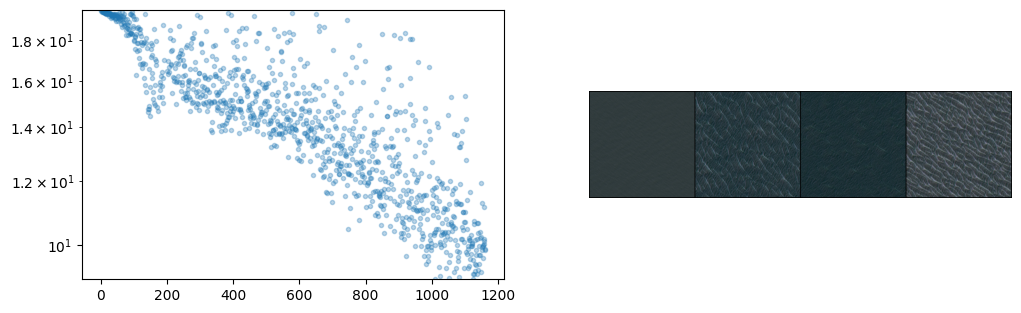

In [31]:
# Train the NCA!
# This takes about 15-20 minutes on a GPU
learn.fit(1)

**What should you see during training?**

1. **Loss curve**: Should decrease from ~1000+ to ~10-50
2. **Preview images**: Start as noise, gradually develop texture patterns

The texture emerges gradually as the NCA learns the update rules that produce the target style!

---

## Section 7: Results and Visualization

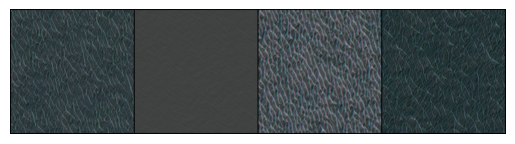

In [32]:
# View the final batch of generated textures
# These are the 4 grids from the last training iteration

# Convert to RGB (first 3 channels) and clip to valid range
rgb = model.to_rgb(learn.preds.detach())

# Arrange into a grid for display
rgb = torchvision.utils.make_grid(rgb)

# Display the result
show_image(rgb.clip(0, 1));

**What does the code above do?**

Shows the final generated textures. You should see patterns that resemble the spiderweb style - radial lines, intersection points, similar coloring.

**Amazing fact:** These complex patterns are generated by just 168 parameters applying the same simple rules everywhere!

### Watching the Texture Grow

One of the coolest things about NCA is watching patterns emerge from nothing. Let's see it in action!

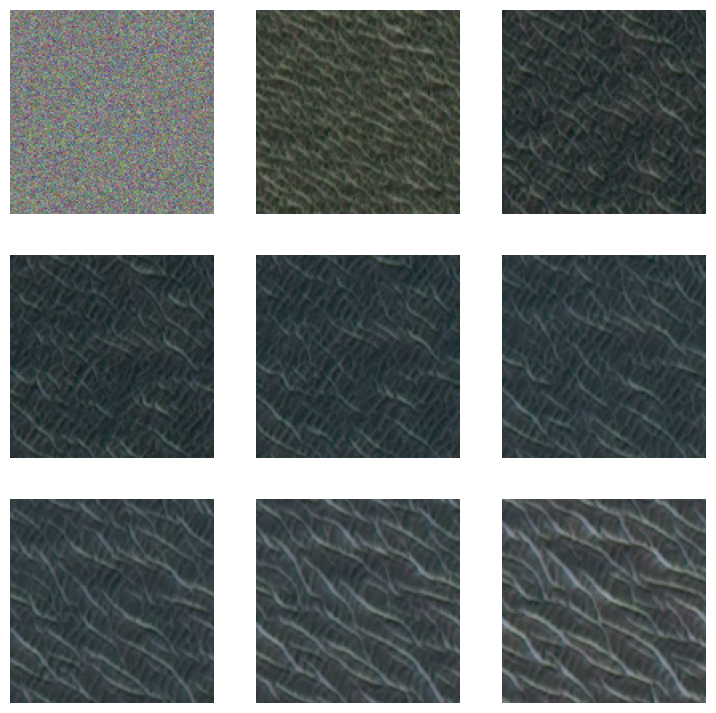

In [33]:
# Watch the NCA grow a texture from random noise!

images = []  # Store snapshots

# Start with very small random noise (near zero)
# Scale by 0.1 to start close to "empty"
x = torch.randn(1, num_channels, 128, 128).to(def_device) * 0.1

# Run the NCA for 900 steps, saving every 100th frame
for i in range(900):
    x = model(x)  # One NCA update step

    # Save a snapshot every 100 steps
    if i % 100 == 0:
        # Convert to RGB, get first image from batch, clip to valid range
        images.append(model.to_rgb(x)[0].clip(0, 1))

# Display the evolution sequence
show_images(images)

**What does the code above do?**

Shows how the texture emerges over time:

1. **Start**: Near-zero random noise
2. **Steps 0-100**: Small fluctuations appear
3. **Steps 100-300**: Patterns begin to form
4. **Steps 300-600**: Clear texture structure emerges
5. **Steps 600-900**: Texture stabilizes and refines

**The magic of self-organization:**
Each cell only looks at its 3×3 neighborhood, yet global patterns emerge!

### 🎮 Interactive: Emergence Lab — grow textures from local rules, live

You just watched *our* NCA grow a texture over 900 steps. To drive home that this isn't a
neural-network parlor trick but a deep principle, here is a **hand-designed** cellular
automaton doing the same thing in real time: the **Gray–Scott reaction–diffusion** system —
the classic model of how animal coats, coral, and fingerprints pattern themselves.

- It uses the **exact same 3×3 Laplacian filter as our NCA**, plus two lines of chemistry.
  That's the entire rule. No training, no parameters beyond two numbers, `f` (feed) and
  `k` (kill).
- **Click and drag on the dish** to inject chemical V and watch structure bloom from your
  touch. The grid wraps around — a torus again!
- Switch **presets** (coral, mitosis, solitons, worms, waves) or drag the `f`/`k` sliders
  *mid-simulation*: every preset is the *same rule* with two constants changed — you are
  scrubbing through a phase space of tiny universes with different physics.

**The connection:** Gray–Scott is what you get when a scientist *hand-writes* the cell
brain. Our NCA replaces those two equations with a 168-parameter network and lets gradient
descent *search* for the rule whose emergent pattern matches a target style image.

In [34]:
# ============================================================================
# INTERACTIVE -- run this cell. It loads ./interactive_viz/nca_emergence_lab.html
# at full width, sized to fit the visualization (setup cell near the top required).
# Keep the 'interactive_viz' folder in the SAME directory as this notebook.
# ============================================================================
show_viz("interactive_viz/nca_emergence_lab.html", height="800px")

In [35]:
# Count the total number of trainable parameters
# sum(p.numel() for p in model.parameters()) counts all parameter values
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params}")

Total parameters: 168


**Only 168 parameters!**

Let's break down where they come from:

| Layer | Calculation | Parameters |
|-------|-------------|------------|
| w1 weights | 8 × 16 × 1 × 1 | 128 |
| w1 bias | 8 | 8 |
| w2 weights | 4 × 8 × 1 × 1 | 32 |
| **Total** | | **168** |

For comparison:
- A typical image classifier: millions of parameters
- GPT-3: 175 billion parameters
- Our NCA: **168 parameters**

This is the power of the NCA approach - tiny models that leverage emergence and self-organization!

---

## Summary

You've learned to build and train a Neural Cellular Automaton! Let's recap:

---

**Key Concepts:**

1. **Cellular Automata**: Grids where each cell updates based on neighbors
   - Local rules → Global patterns (emergence)
   - Classic example: Conway's Game of Life

2. **Neural Cellular Automata**: CA with learned update rules
   - Continuous cell states (not just alive/dead)
   - Neural network "brain" learns the rules
   - Can be trained with gradient descent

3. **NCA Architecture**:
   - **Perception**: Fixed filters detect neighbors (identity, Sobel, Laplacian)
   - **Brain**: Tiny neural network (16 → 8 → 4)
   - **Update**: Add predicted change with random mask

4. **Training Tricks**:
   - **Pool of grids**: Patterns evolve across training iterations
   - **Multi-step forward**: Run NCA 32-96 times per loss computation
   - **Occasional reset**: Ensure NCA can grow from scratch
   - **Gradient normalization**: Stabilize training

5. **Style Loss**: Same Gram matrix approach as style transfer

---

**Amazing Properties:**

- **168 parameters** generate complex textures
- **Resolution independent**: Train on 128×128, run on any size
- **Self-healing**: Damage can be repaired by continuing to run
- **Tileable**: Circular padding creates seamless textures

---

**Things to Try:**

- Different style images (paintings, photographs, abstract patterns)
- More/fewer hidden channels
- Different perception filters
- Running for more/fewer steps
- Larger grid sizes

---

**Further Reading:**

- [Growing Neural Cellular Automata](https://distill.pub/2020/growing-ca/)
- [Self-classifying MNIST Digits](https://distill.pub/2020/selforg/)
- [Texture Generation with NCA](https://arxiv.org/abs/2105.07299)